# Portfolio Optimization Library Comparison

**Docker image**: `ml4t`

This notebook compares three popular Python libraries for portfolio optimization:
PyPortfolioOpt, Riskfolio-Lib, and skfolio. It demonstrates how different libraries
approach the same optimization problems and evaluates results with ml4t-diagnostic.

**Learning Objectives**:
- Use PyPortfolioOpt for classic MVO and Black-Litterman
- Apply Riskfolio-Lib for 22 risk measures and factor models
- Explore skfolio's sklearn-compatible API (supports built-in cross-validation)
- Compare turnover, concentration, and Sharpe across libraries

**Book Reference**: Chapter 17, §17.7 (Comparing Allocator Performance)

**Prerequisites**: `02_mean_variance_optimization`, `03_robust_optimization`

## Library Overview

| Feature | PyPortfolioOpt | Riskfolio-Lib | skfolio |
|---------|----------------|---------------|----------|
| **Focus** | Accessible MVO | Comprehensive risk measures | ML integration |
| **Risk Measures** | Variance, CVaR, Semi-variance | 22 convex measures | Variance, CVaR, MDD |
| **ML Integration** | Limited | Limited | sklearn API |
| **Cross-validation** | Manual | Manual | Built-in (walk-forward, CPCV) |
| **Black-Litterman** | Yes | Yes (+ Bayesian variants) | Yes |
| **HRP/HERC** | Yes | Yes | Yes |
| **Constraints** | Flexible | Very flexible | sklearn pipeline |
| **Maintenance** | Lower activity | Active | Very active |

All three libraries remain widely used and capable. For production systems,
evaluate each library's recent commit history and release cadence.

## Imports & Settings

### cvxpy Compatibility Check

Riskfolio-Lib relies on a small set of cvxpy internals. Surface a clear error early
if the installed cvxpy is incompatible, rather than failing deep inside an optimizer.

In [1]:
"""Portfolio Optimization Library Comparison — benchmark cvxpy, riskfolio-lib, and PyPortfolioOpt on the same data."""

import warnings

import cvxpy.reductions.matrix_stuffing as cvxpy_matrix_stuffing
from cvxpy.problems.problem import Problem as _CvxpyProblem

missing_cvxpy_symbols = [
    name
    for name in ("extract_lower_bounds", "extract_upper_bounds")
    if not hasattr(cvxpy_matrix_stuffing, name)
]
if not hasattr(_CvxpyProblem, "_supports_cpp"):
    missing_cvxpy_symbols.append("Problem._supports_cpp")
if missing_cvxpy_symbols:
    raise RuntimeError(
        "Incompatible cvxpy runtime for the Riskfolio-Lib comparison notebook. "
        "Install the supported cvxpy stack instead of patching site-packages at runtime. "
        f"Missing symbols: {missing_cvxpy_symbols}"
    )

### Third-Party Imports

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import riskfolio as rp
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

# Portfolio optimization libraries

### ml4t and Project Imports

In [3]:
# ml4t libraries for diagnostics and execution-aware backtesting
from ml4t.backtest import (
    BacktestConfig,
    CommissionType,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import SlippageType
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from pypfopt import (
    EfficientCVaR,
    EfficientFrontier,
    HRPOpt,
    expected_returns,
    objective_functions,
    risk_models,
)
from skfolio import RiskMeasure
from skfolio.cluster import HierarchicalClustering, LinkageMethod
from skfolio.distance import PearsonDistance
from skfolio.model_selection import WalkForward
from skfolio.model_selection import cross_val_predict as skf_cross_val_predict
from skfolio.optimization import HierarchicalRiskParity, MeanRisk, ObjectiveFunction

from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

In [4]:
# Production defaults — Papermill overrides for CI testing
MAX_SYMBOLS = 0  # 0 = all
SEED = 42

In [5]:
set_global_seeds(SEED)

## Load Data

Load ETF price data from canonical dataset for portfolio optimization.

### Universe and Date Range

In [6]:
# ETF Universe - diversified across asset classes
_FULL_UNIVERSE = [
    "SPY",
    "QQQ",
    "IWM",
    "EFA",
    "EEM",  # Equities
    "AGG",
    "TLT",
    "LQD",  # Fixed Income
    "GLD",
    "VNQ",
    "DBC",  # Alternatives
]
# Configuration
SYMBOLS = _FULL_UNIVERSE
START_DATE = "2018-01-01"
END_DATE = "2024-12-01"

### Load and Filter ETF Panel

In [7]:
print(f"Loading {len(SYMBOLS)} ETFs from canonical data...")
etf_data = load_etfs()
etf_filtered = etf_data.filter(
    (pl.col("symbol").is_in(SYMBOLS))
    & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_datetime())
)

Loading 11 ETFs from canonical data...


### Pivot to Wide Returns Matrix

In [8]:
# Pivot to wide format for returns
prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
    .ffill()
    .dropna()
)
print(f"Loaded {prices.shape[1]} ETFs, {prices.shape[0]} days")

# Daily returns
returns = prices.pct_change().dropna()
tickers = prices.columns.tolist()
num_stocks = len(tickers)

Loaded 11 ETFs, 1740 days


The shared dataset is important for a fair comparison. Any performance differences
below come from the optimizer APIs and objectives, not from different asset universes
or sample windows.

In [9]:
# Risk-free rate from FREDProvider (fallback to 4% if API key not available)
try:
    from ml4t.data.providers.fred import FREDProvider

    fred = FREDProvider()
    dgs3mo = fred.fetch_ohlcv("DGS3MO", START_DATE, END_DATE)
    if dgs3mo.is_empty():
        raise ValueError("Empty result")
    risk_free_rate = dgs3mo["close"].mean() / 100
    print("Loaded risk-free rate from FREDProvider")
except (ImportError, ValueError, KeyError, OSError, RuntimeError):
    risk_free_rate = 0.04
    print("FREDProvider not available, using fallback rate: 4%")

print(f"Risk-free rate: {risk_free_rate:.2%}")

2026-06-13 00:12:33 [debug    ] Rate limiter initialized       max_calls=100 period=60.0 provider=fred


2026-06-13 00:12:33 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-06-13 00:12:33 [info     ] Initialized FRED provider      name=FREDProvider


2026-06-13 00:12:33 [info     ] Fetching daily OHLCV           end=2024-12-01 name=FREDProvider start=2018-01-01 symbol=DGS3MO vintage_date=None


2026-06-13 00:12:34 [info     ] Fetched 1805 records           name=FREDProvider symbol=DGS3MO


Loaded risk-free rate from FREDProvider
Risk-free rate: 2.41%


## Part 1: PyPortfolioOpt

PyPortfolioOpt is the most accessible library with good defaults.

### Expected Returns & Covariance

In [10]:
# Historical mean returns (annualized with compounding)
mu = expected_returns.mean_historical_return(
    prices, returns_data=False, compounding=True, frequency=252
)

# Sample covariance (annualized)
S = risk_models.sample_cov(prices, frequency=252)

print(f"Expected returns range: [{mu.min():.2%}, {mu.max():.2%}]")
print(f"Covariance matrix shape: {S.shape}")

Expected returns range: [-1.71%, 19.23%]
Covariance matrix shape: (11, 11)


PyPortfolioOpt is easiest to read because it exposes the classical MVO inputs
directly. That simplicity is valuable for teaching, but it also means the user
has to be explicit about robustness choices like shrinkage and regularization.

### Max Sharpe Portfolio

In [11]:
ef = EfficientFrontier(mu, S)
weights_sharpe = ef.max_sharpe(risk_free_rate=risk_free_rate)
ret, vol, sr = ef.portfolio_performance(verbose=True, risk_free_rate=risk_free_rate)

weights_pypfopt_sharpe = pd.Series(weights_sharpe)

Expected annual return: 14.3%
Annual volatility: 14.1%
Sharpe Ratio: 0.84


### Min Volatility Portfolio

In [12]:
ef = EfficientFrontier(mu, S)
weights_minvol = ef.min_volatility()
ret, vol, sr = ef.portfolio_performance(verbose=True, risk_free_rate=risk_free_rate)

weights_pypfopt_minvol = pd.Series(weights_minvol)

Expected annual return: 1.9%
Annual volatility: 5.7%
Sharpe Ratio: -0.10


### CVaR Optimization

In [13]:
cvar = EfficientCVaR(mu, returns, beta=0.95)
weights_cvar = cvar.efficient_return(target_return=0.15)
cvar.portfolio_performance(verbose=True)

weights_pypfopt_cvar = pd.Series(cvar.clean_weights())

Expected annual return: 15.0%
Conditional Value at Risk: 2.19%


### Hierarchical Risk Parity (HRP)

In [14]:
hrp = HRPOpt(returns)
hrp.optimize(linkage_method="ward")
hrp.portfolio_performance(verbose=True)

weights_pypfopt_hrp = pd.Series(hrp.clean_weights())

Expected annual return: 4.1%
Annual volatility: 7.5%
Sharpe Ratio: 0.55


### Covariance Shrinkage (Ledoit-Wolf)

In [15]:
# Shrinkage estimator for more robust covariance
S_shrunk = risk_models.CovarianceShrinkage(prices).ledoit_wolf()

ef_shrunk = EfficientFrontier(mu, S_shrunk)
weights_shrunk = ef_shrunk.max_sharpe(risk_free_rate=risk_free_rate)
ef_shrunk.portfolio_performance(verbose=True, risk_free_rate=risk_free_rate)

weights_pypfopt_shrunk = pd.Series(weights_shrunk)

Expected annual return: 14.3%
Annual volatility: 14.1%
Sharpe Ratio: 0.84


## Part 2: Riskfolio-Lib

Riskfolio-Lib offers the most comprehensive set of risk measures.

In [16]:
# Create portfolio object
port = rp.Portfolio(returns=returns)

# Estimate statistics
port.assets_stats(method_mu="hist", method_cov="hist")

# Set solver
port.solvers = ["CLARABEL"]

### Available Risk Measures

Riskfolio supports 22 risk measures:
- **Deviation-based**: MV, MAD, MSV, GMD, KT, SKT
- **Quantile-based**: CVaR, EVaR, RLVaR, WR
- **Drawdown-based**: MDD, ADD, CDaR, EDaR, RLDaR, UCI

### Max Sharpe with Different Risk Measures

In [17]:
risk_measures = {
    "MV": "Standard Deviation",
    "CVaR": "Conditional VaR",
    "MDD": "Max Drawdown",
    "CDaR": "Conditional DaR",
}

# Riskfolio 7.2.1 fails this sample's Sharpe solve when a positive rf is supplied directly.
riskfolio_rf = 0.0

riskfolio_weights = {}
for rm, name in risk_measures.items():
    result = port.optimization(
        model="Classic",
        rm=rm,
        obj="Sharpe",
        rf=riskfolio_rf,
        hist=True,
    )
    if result is None or "weights" not in result.columns:
        raise RuntimeError(f"Riskfolio optimization returned no weights for {name}.")
    riskfolio_weights[name] = result["weights"].values.flatten()
    n_pos = int((result["weights"] > 0.001).sum())
    print(f"{name}: {n_pos} positions")

Standard Deviation: 2 positions
Conditional VaR: 2 positions
Max Drawdown: 3 positions


Conditional DaR: 4 positions


### Risk Parity

In [18]:
# Risk parity: equal risk contribution from each asset
weights_rp = port.rp_optimization(
    model="Classic",
    rm="MV",
    rf=riskfolio_rf,
    b=None,  # Equal risk contribution
    hist=True,
)
if weights_rp is None or "weights" not in weights_rp.columns:
    raise RuntimeError("Riskfolio risk parity optimization returned no weights.")
riskfolio_weights["Risk Parity"] = weights_rp["weights"].values.flatten()
n_pos = int((weights_rp["weights"] > 0.001).sum())
print(f"Risk Parity: {n_pos} positions")

Risk Parity: 11 positions


### Efficient Frontier Comparison

In [19]:
# Compute efficient frontiers for different risk measures
frontier_mv = port.efficient_frontier(
    model="Classic", rm="MV", points=50, rf=riskfolio_rf, hist=True
)
frontier_cvar = port.efficient_frontier(
    model="Classic", rm="CVaR", points=50, rf=riskfolio_rf, hist=True
)


# Convert to plottable format
def frontier_to_df(frontier, cov, name):
    """Convert riskfolio frontier to DataFrame with risk-return."""
    results = []
    mu_flat = port.mu.values.flatten()  # Ensure 1D array
    for col in frontier.columns:
        w = frontier[col].values
        ret = (w @ mu_flat) * 252
        vol = np.sqrt(w @ cov @ w) * np.sqrt(252)
        results.append({"return": ret, "volatility": vol, "frontier": name})
    return pd.DataFrame(results)


cov_np = port.cov.values
ef_mv = frontier_to_df(frontier_mv, cov_np, "Mean-Variance")
ef_cvar = frontier_to_df(frontier_cvar, cov_np, "CVaR")

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(
.venv/lib/python3.14/site-packages/kaleido/scopes/base.py:188: DeprecationWarning: setDaemon() is deprecated, set the daemon attribute instead
  self._std_error_thread.setDaemon(True)


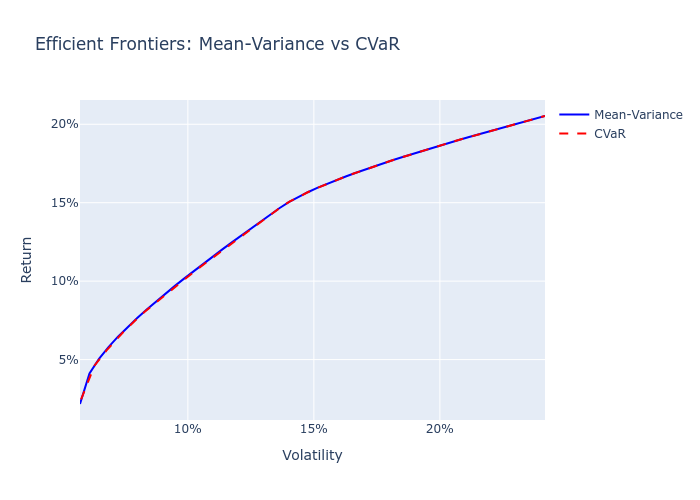

In [20]:
# Plot both efficient frontiers
fig = go.Figure()

fig.add_scatter(
    x=ef_mv["volatility"],
    y=ef_mv["return"],
    mode="lines",
    name="Mean-Variance",
    line=dict(color="blue", width=2),
)

fig.add_scatter(
    x=ef_cvar["volatility"],
    y=ef_cvar["return"],
    mode="lines",
    name="CVaR",
    line=dict(color="red", width=2, dash="dash"),
)

fig.update_layout(
    title="Efficient Frontiers: Mean-Variance vs CVaR",
    xaxis_title="Volatility",
    yaxis_title="Return",
    xaxis_tickformat=".0%",
    yaxis_tickformat=".0%",
    height=500,
)
fig.show()

**Interpretation**: The frontier comparison makes the objective-function trade-off
visible. CVaR-aware portfolios usually accept a slightly worse variance-based fit
in exchange for better behavior in the left tail.

## Part 3: skfolio

skfolio is the newest of the three libraries surveyed here; it exposes a sklearn-style
fit/predict API with built-in cross-validation and hyperparameter tuning.

### Mean-Risk Optimization

skfolio uses sklearn-compatible estimators that can be used in pipelines.

In [21]:
# Max Sharpe with skfolio
model_sharpe = MeanRisk(
    objective_function=ObjectiveFunction.MAXIMIZE_RATIO,
    risk_measure=RiskMeasure.VARIANCE,
)
model_sharpe.fit(returns)

print(f"skfolio Max Sharpe - Fitted {len(model_sharpe.weights_)} assets")
weights_skfolio_sharpe = pd.Series(model_sharpe.weights_, index=tickers)

skfolio Max Sharpe - Fitted 11 assets


In [22]:
# Min Variance with skfolio
model_minvar = MeanRisk(
    objective_function=ObjectiveFunction.MINIMIZE_RISK,
    risk_measure=RiskMeasure.VARIANCE,
)
model_minvar.fit(returns)

weights_skfolio_minvar = pd.Series(model_minvar.weights_, index=tickers)

In [23]:
# CVaR optimization
model_cvar = MeanRisk(
    objective_function=ObjectiveFunction.MINIMIZE_RISK,
    risk_measure=RiskMeasure.CVAR,
)
model_cvar.fit(returns)

weights_skfolio_cvar = pd.Series(model_cvar.weights_, index=tickers)

### Hierarchical Risk Parity

In [24]:
# HRP with skfolio
model_hrp = HierarchicalRiskParity(
    risk_measure=RiskMeasure.VARIANCE,
    distance_estimator=PearsonDistance(),
    hierarchical_clustering_estimator=HierarchicalClustering(linkage_method=LinkageMethod.WARD),
)
model_hrp.fit(returns)

weights_skfolio_hrp = pd.Series(model_hrp.weights_, index=tickers)

### sklearn Integration: Walk-Forward Cross-Validation

One of skfolio's key advantages is native sklearn compatibility,
including built-in walk-forward and combinatorial purged cross-validation.
Here we run walk-forward CV to evaluate the Max Sharpe model out-of-sample.

In [25]:
# Walk-forward cross-validation: 1 year train, 1 quarter test
cv = WalkForward(train_size=252, test_size=63)
n_splits = cv.get_n_splits(returns)
print(f"Walk-forward CV: {n_splits} splits (252d train / 63d test)")

# Run CV on the Max Sharpe model — produces out-of-sample Portfolio per fold
pred = skf_cross_val_predict(model_sharpe, returns, cv=cv)

# pred is a skfolio Population (collection of test-fold Portfolios)
print(f"\nOut-of-sample results across {n_splits} folds:")
print(f"  Mean return (ann.): {pred.annualized_mean:.4f}")
print(f"  Sharpe ratios per fold: {[f'{p.annualized_sharpe_ratio:.2f}' for p in pred]}")

Walk-forward CV: 23 splits (252d train / 63d test)



Out-of-sample results across 23 folds:
  Mean return (ann.): 0.0900
  Sharpe ratios per fold: ['2.83', '4.47', '3.05', '0.61', '-0.85', '3.28', '1.26', '1.33', '-1.69', '2.56', '1.34', '1.39', '1.10', '-2.33', '0.44', '-0.97', '0.65', '-1.61', '-1.23', '3.35', '4.02', '2.46', '1.56']


**Interpretation**: This is the main reason to care about skfolio. It treats
portfolio construction as an estimator that can be cross-validated, which is a
better fit for ML workflows than judging allocations on one full-sample backtest.

In [26]:
# Display skfolio portfolio performance
print("\n=== skfolio Portfolio Summary ===")
portfolios_skf = {
    "Max Sharpe": weights_skfolio_sharpe,
    "Min Variance": weights_skfolio_minvar,
    "CVaR": weights_skfolio_cvar,
    "HRP": weights_skfolio_hrp,
}

for name, w in portfolios_skf.items():
    n_pos = (w.abs() > 0.001).sum()
    max_w = w.max()
    print(f"{name}: {n_pos} positions, max weight {max_w:.1%}")


=== skfolio Portfolio Summary ===
Max Sharpe: 2 positions, max weight 59.2%
Min Variance: 3 positions, max weight 89.7%
CVaR: 4 positions, max weight 87.6%
HRP: 11 positions, max weight 38.3%


These summary lines are a quick implementation check: if one model keeps producing
extremely concentrated portfolios, it may be using the same objective as the others
but with very different practical behavior.

## Part 4: Comprehensive Comparison

Let's compare all optimized portfolios using ml4t-diagnostic.

In [27]:
# Collect all portfolio weights
all_portfolios = {
    # PyPortfolioOpt
    "PPO: Max Sharpe": weights_pypfopt_sharpe.values,
    "PPO: Min Vol": weights_pypfopt_minvol.values,
    "PPO: CVaR": weights_pypfopt_cvar.values,
    "PPO: HRP": weights_pypfopt_hrp.values,
    "PPO: Shrinkage": weights_pypfopt_shrunk.values,
    # Riskfolio-Lib
    "RF: Std Dev": riskfolio_weights["Standard Deviation"],
    "RF: CVaR": riskfolio_weights["Conditional VaR"],
    "RF: Max DD": riskfolio_weights["Max Drawdown"],
    "RF: Risk Parity": riskfolio_weights["Risk Parity"],
    # skfolio
    "SKF: Max Sharpe": weights_skfolio_sharpe.values,
    "SKF: Min Var": weights_skfolio_minvar.values,
    "SKF: CVaR": weights_skfolio_cvar.values,
    "SKF: HRP": weights_skfolio_hrp.values,
}

In [28]:
# Compute portfolio returns for each strategy
returns_np = returns.values
dates = returns.index.tolist()

portfolio_returns = {}
for name, weights in all_portfolios.items():
    pf_ret = returns_np @ weights
    portfolio_returns[name] = pf_ret

### Evaluate with ml4t-diagnostic

In [29]:
# Comprehensive evaluation using PortfolioAnalysis
evaluation_results = []

for name, pf_returns in portfolio_returns.items():
    pa = PortfolioAnalysis(
        returns=pl.Series("returns", pf_returns),
        dates=pl.Series("date", dates),
        risk_free=risk_free_rate / 252,
        periods_per_year=252,
    )

    metrics = pa.compute_summary_stats()

    evaluation_results.append(
        {
            "Portfolio": name,
            "Annual Return": metrics.annual_return,
            "Annual Vol": metrics.annual_volatility,
            "Sharpe": metrics.sharpe_ratio,
            "Sortino": metrics.sortino_ratio,
            "Calmar": metrics.calmar_ratio,
            "Max DD": metrics.max_drawdown,
            "VaR 95%": metrics.var_95,
            "CVaR 95%": metrics.cvar_95,
            "Win Rate": metrics.win_rate,
        }
    )

eval_df = pl.DataFrame(evaluation_results)
eval_df

Portfolio,Annual Return,Annual Vol,Sharpe,Sortino,Calmar,Max DD,VaR 95%,CVaR 95%,Win Rate
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""PPO: Max Sharpe""",0.151757,0.141027,1.072012,1.015804,0.681103,-0.222811,-0.013705,-0.020296,0.566993
"""PPO: Min Vol""",0.020234,0.057204,0.377218,0.34365,0.137064,-0.147627,-0.005374,-0.008404,0.546291
"""PPO: CVaR""",0.159364,0.151268,1.052905,0.993917,0.660463,-0.241291,-0.014688,-0.021887,0.566417
"""PPO: HRP""",0.038774,0.07456,0.546328,0.508937,0.198489,-0.195344,-0.006871,-0.010753,0.543991
"""PPO: Shrinkage""",0.152161,0.141487,1.071464,1.01641,0.680026,-0.223757,-0.013861,-0.020368,0.565842
…,…,…,…,…,…,…,…,…,…
"""RF: Risk Parity""",0.05539,0.091903,0.631695,0.57952,0.272481,-0.203279,-0.008675,-0.013385,0.556067
"""SKF: Max Sharpe""",0.148202,0.137369,1.074321,1.024544,0.690521,-0.214624,-0.013565,-0.019723,0.562967
"""SKF: Min Var""",0.020223,0.057204,0.377017,0.343469,0.136995,-0.147616,-0.005374,-0.008404,0.546291


**Interpretation**: Differences across libraries are often smaller than the marketing
suggests. The practical decision usually comes down to workflow fit, constraints, and
validation tooling rather than to a large persistent edge in raw portfolio metrics.

### Execution-Aware Bridge with ml4t-backtest

Vectorized matrix multiplication is useful for comparing optimizers under identical assumptions.
To connect this to deployable execution, replay one optimized portfolio through Engine.

The bridge strategy submits the chosen library weights once and lets the engine
model fills, slippage, and commissions.

In [30]:
class StaticWeightStrategy(Strategy):
    def __init__(self, target_weights: dict[str, float], allow_short: bool):
        self.target_weights = target_weights
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=100.0,
                min_weight_change=0.001,
                allow_fractional=True,
                allow_short=allow_short,
            )
        )
        self._submitted = False

    def on_data(self, timestamp, data, context, broker):
        if self._submitted:
            return
        targets = {asset: weight for asset, weight in self.target_weights.items() if asset in data}
        if targets:
            self.executor.execute(targets, data, broker)
            self._submitted = True

In [31]:
# Build engine inputs from the selected library portfolio and the price panel.
bridge_name = "PPO: Max Sharpe"
engine_target_weights = {
    ticker: float(weight)
    for ticker, weight in zip(tickers, all_portfolios[bridge_name], strict=False)
    if abs(float(weight)) > 1e-8
}
allow_short_engine = any(weight < 0 for weight in engine_target_weights.values())

prices_panel = pl.from_pandas(prices.reset_index())
ts_col = prices_panel.columns[0]
if ts_col != "timestamp":
    prices_panel = prices_panel.rename({ts_col: "timestamp"})
prices_long = (
    prices_panel.unpivot(index="timestamp", variable_name="symbol", value_name="close")
    .with_columns(
        [
            pl.col("timestamp").cast(pl.Datetime("us")),
            pl.col("close").alias("open"),
            pl.col("close").alias("high"),
            pl.col("close").alias("low"),
            pl.lit(1_000_000).alias("volume"),
        ]
    )
    .sort(["timestamp", "symbol"])
)

In [32]:
# Run the execution-aware simulation and collect daily returns.
engine = Engine(
    feed=DataFeed(prices_df=prices_long),
    strategy=StaticWeightStrategy(engine_target_weights, allow_short=allow_short_engine),
    config=BacktestConfig(
        initial_cash=100_000.0,
        execution_mode=ExecutionMode.NEXT_BAR,
        commission_type=CommissionType.PERCENTAGE,
        commission_rate=0.0005,
        slippage_type=SlippageType.PERCENTAGE,
        slippage_rate=0.0005,
        allow_short_selling=allow_short_engine,
    ),
)

engine_daily = (
    engine.run()
    .to_daily_pnl()
    .select(
        pl.col("date").cast(pl.Datetime("us")).alias("date"),
        pl.col("return_pct").alias("engine_return"),
    )
)
vectorized_daily = pl.DataFrame(
    {
        "date": pl.Series(dates).cast(pl.Datetime("us")),
        "vectorized_return": portfolio_returns[bridge_name],
    }
)

In [33]:
# Compare vectorized and engine results on overlapping dates.
bridge = (
    vectorized_daily.join(engine_daily, on="date", how="inner")
    .drop_nulls(["vectorized_return", "engine_return"])
    .sort("date")
)

vec_pa = PortfolioAnalysis(
    returns=bridge["vectorized_return"], dates=bridge["date"], periods_per_year=252
)
eng_pa = PortfolioAnalysis(
    returns=bridge["engine_return"], dates=bridge["date"], periods_per_year=252
)
vec_stats = vec_pa.compute_summary_stats()
eng_stats = eng_pa.compute_summary_stats()

print(f"Execution bridge ({bridge_name}):")
print(
    f"  Vectorized Sharpe={vec_stats.sharpe_ratio:.3f}, Engine Sharpe={eng_stats.sharpe_ratio:.3f}"
)
print(f"  Vectorized MaxDD={vec_stats.max_drawdown:.2%}, Engine MaxDD={eng_stats.max_drawdown:.2%}")

Execution bridge (PPO: Max Sharpe):
  Vectorized Sharpe=1.073, Engine Sharpe=0.999
  Vectorized MaxDD=-22.28%, Engine MaxDD=-25.93%


**Interpretation**: Library rankings only matter if they survive the same execution
assumptions. This bridge filters out optimizers that win on paper but degrade quickly
once fills and trading costs are applied.

### Visualization: Portfolio Comparison

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


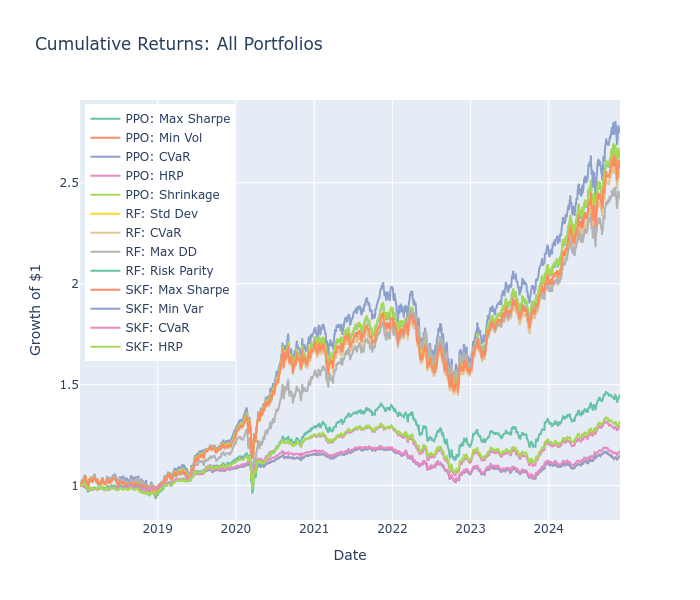

In [34]:
# Cumulative returns comparison
fig = go.Figure()

colors = px.colors.qualitative.Set2

for i, (name, pf_ret) in enumerate(portfolio_returns.items()):
    cum_ret = (1 + pf_ret).cumprod()
    fig.add_scatter(
        x=dates,
        y=cum_ret,
        mode="lines",
        name=name,
        line=dict(color=colors[i % len(colors)]),
    )

fig.update_layout(
    title="Cumulative Returns: All Portfolios",
    xaxis_title="Date",
    yaxis_title="Growth of $1",
    height=600,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


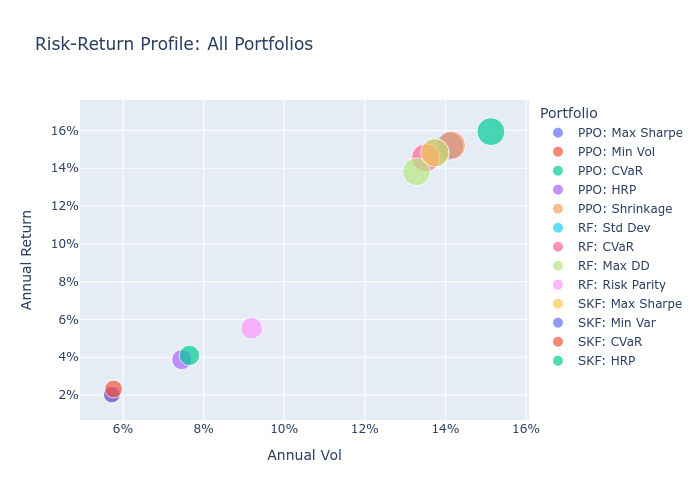

In [35]:
# Risk-Return scatter
eval_pd = eval_df.to_pandas()

fig = px.scatter(
    eval_pd,
    x="Annual Vol",
    y="Annual Return",
    color="Portfolio",
    size="Sharpe",
    size_max=20,
    hover_data=["Sharpe", "Sortino", "Max DD"],
    title="Risk-Return Profile: All Portfolios",
)

fig.update_layout(
    xaxis_tickformat=".0%",
    yaxis_tickformat=".0%",
    height=500,
)
fig.show()

**Interpretation**: The scatter plot is useful for spotting dominance relationships.
If several portfolios occupy the same neighborhood, the library choice should be
driven by tooling and constraints rather than by tiny performance differences.

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


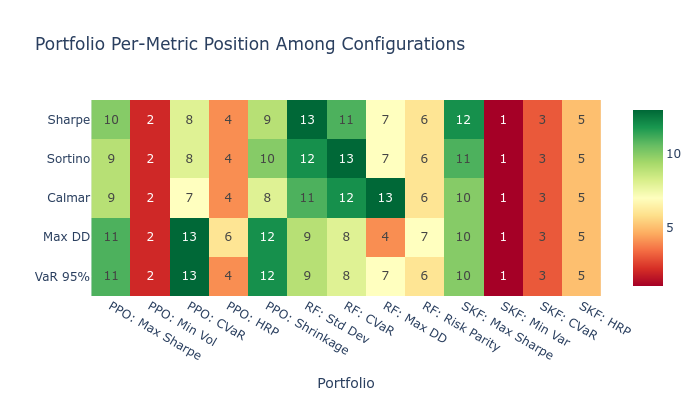

In [36]:
# Metrics heatmap
metrics_cols = ["Sharpe", "Sortino", "Calmar", "Max DD", "VaR 95%"]

# Normalize for heatmap (higher is better except Max DD and VaR)
heatmap_data = eval_pd.set_index("Portfolio")[metrics_cols].copy()
heatmap_data["Max DD"] = -heatmap_data["Max DD"]  # Flip sign
heatmap_data["VaR 95%"] = -heatmap_data["VaR 95%"]  # Flip sign

# Rank (higher = better)
ranked = heatmap_data.rank(axis=0)

fig = px.imshow(
    ranked.T,
    x=ranked.index,
    y=ranked.columns,
    color_continuous_scale="RdYlGn",
    title="Portfolio Per-Metric Position Among Configurations",
    text_auto=".0f",
)
fig.update_layout(height=400)
fig.show()

The ranking heatmap is a compact way to see whether a portfolio is consistently good
or merely wins one metric. Production selection usually favors methods that stay near
the top across several criteria instead of topping a single column.

### Weight Distribution Comparison

In [37]:
# Compare concentration across portfolios
concentration_stats = []

for name, weights in all_portfolios.items():
    n_positions = (np.abs(weights) > 0.001).sum()
    max_weight = np.max(weights)
    top5_weight = np.sort(weights)[-5:].sum()
    hhi = (weights**2).sum()  # Herfindahl-Hirschman Index

    concentration_stats.append(
        {
            "Portfolio": name,
            "Positions": n_positions,
            "Max Weight": max_weight,
            "Top 5 Weight": top5_weight,
            "HHI": hhi,
        }
    )

conc_df = pl.DataFrame(concentration_stats)
conc_df

Portfolio,Positions,Max Weight,Top 5 Weight,HHI
str,i64,f64,f64,f64
"""PPO: Max Sharpe""",2,0.554947,1.0,0.506038
"""PPO: Min Vol""",3,0.896886,1.0,0.811695
"""PPO: CVaR""",2,0.52819,1.0,0.501589
"""PPO: HRP""",11,0.44084,0.84165,0.253688
"""PPO: Shrinkage""",2,0.550674,1.0,0.505136
…,…,…,…,…
"""RF: Risk Parity""",11,0.215733,0.681757,0.118736
"""SKF: Max Sharpe""",2,0.591984,1.0,0.516919
"""SKF: Min Var""",3,0.89695,0.999998,0.811811


**Interpretation**: Concentration is an implementation risk, not just a stylistic
concern. Portfolios with very high HHI or a dominant top-5 weight are more exposed
to estimation error, turnover, and mandate breaches.

### Concentration Bar Chart — Subplot Scaffolding

In [38]:
# Bar chart: positions and concentration
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Number of Positions", "Portfolio Concentration (HHI)"],
)
portfolios = conc_df["Portfolio"].to_list()

### Populate Position-Count and HHI Traces

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


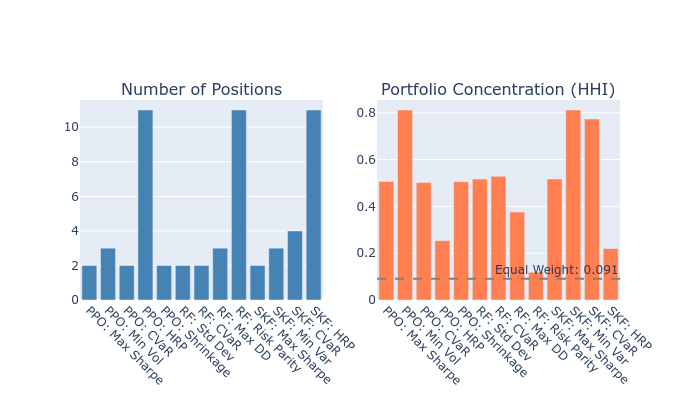

In [39]:
fig.add_bar(
    x=portfolios,
    y=conc_df["Positions"].to_list(),
    name="Positions",
    marker_color="steelblue",
    row=1,
    col=1,
)

fig.add_bar(
    x=portfolios,
    y=conc_df["HHI"].to_list(),
    name="HHI",
    marker_color="coral",
    row=1,
    col=2,
)

# Add reference line for equal weight HHI
equal_weight_hhi = 1 / num_stocks
fig.add_hline(
    y=equal_weight_hhi,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"Equal Weight: {equal_weight_hhi:.3f}",
    row=1,
    col=2,
)

fig.update_layout(height=400, showlegend=False)
fig.update_xaxes(tickangle=45)
fig.show()

## Part 5: Practical Considerations

### Transaction Costs

In [40]:
# Optimize with transaction costs
ef = EfficientFrontier(mu, S)

# Starting from equal-weight portfolio
initial_weights = np.full(num_stocks, 1 / num_stocks)

# Add transaction cost penalty (1% commission)
ef.add_objective(objective_functions.transaction_cost, w_prev=initial_weights, k=0.01)

ef.min_volatility()
weights_with_cost = pd.Series(ef.clean_weights())

# Compare to without cost
ef_no_cost = EfficientFrontier(mu, S)
ef_no_cost.min_volatility()
weights_no_cost = pd.Series(ef_no_cost.clean_weights())

# Turnover comparison
turnover_with = np.abs(weights_with_cost.values - initial_weights).sum()
turnover_without = np.abs(weights_no_cost.values - initial_weights).sum()

print(f"Turnover without cost penalty: {turnover_without:.2%}")
print(f"Turnover with cost penalty:    {turnover_with:.2%}")

Turnover without cost penalty: 161.20%
Turnover with cost penalty:    49.59%


**Interpretation**: Even a simple transaction-cost penalty can materially shrink
turnover. In practice that often matters more than squeezing a few extra basis
points from an unconstrained optimum.

### L2 Regularization for Diversification

In [41]:
# Regularized optimization
ef_reg = EfficientFrontier(mu, S)
ef_reg.add_objective(objective_functions.L2_reg, gamma=0.5)
ef_reg.max_sharpe(risk_free_rate=risk_free_rate)
weights_regularized = pd.Series(ef_reg.clean_weights())

print(f"Unregularized positions: {(weights_pypfopt_sharpe > 0.001).sum()}")
print(f"Regularized positions:   {(weights_regularized > 0.001).sum()}")

Unregularized positions: 2
Regularized positions:   7


## API Ergonomics Comparison

Having used all three libraries on the same data and objectives, a clear picture
of their respective strengths emerges:

**PyPortfolioOpt** has the most intuitive API for standard tasks. Creating an
`EfficientFrontier`, calling `max_sharpe()`, and inspecting `portfolio_performance()`
requires minimal boilerplate. Its `clean_weights()` method and built-in transaction
cost objectives are practical touches. The trade-off is a narrower set of risk
measures and no native cross-validation support.

**Riskfolio-Lib** excels in breadth: 22 risk measures, multiple covariance estimators,
and factor model support via a single `Portfolio` object. The `optimization()` method
accepts string codes for risk measures (`"MV"`, `"CVaR"`, `"MDD"`), making it easy
to sweep across objectives programmatically. The API is slightly more verbose, but
the efficient frontier and risk-contribution tools are the most complete of the three.

**skfolio** stands out for ML integration. Models are sklearn estimators with `fit()` /
`predict()` semantics, meaning they slot into `Pipeline`, `GridSearchCV`, and
walk-forward cross-validation without adapters. This is a decisive advantage when
portfolio construction is one stage in a larger ML workflow. The trade-off is
higher overhead for simple one-shot optimizations.

| Criterion | PyPortfolioOpt | Riskfolio-Lib | skfolio |
|-----------|----------------|---------------|---------|
| Quickest to prototype | Best | Good | Good |
| Risk measure breadth | ~5 | 22 | ~8 |
| ML pipeline integration | Manual | Manual | Native (sklearn) |
| Cross-validation | Manual | Manual | Built-in (WalkForward, CPCV) |
| Factor models | No | Yes | Limited |
| Transaction cost objectives | Yes | Yes | Via constraints |
| Maintainer activity (2025) | Lower | Active | Very active |

## Persist Evaluation Table

In [42]:
# Save comparison results for downstream chapters and case studies.
output_dir = get_output_dir(17, "portfolio_comparison")
output_dir.mkdir(exist_ok=True)
eval_df.write_parquet(output_dir / "portfolio_comparison_results.parquet")
print(f"Saved results to {output_dir / 'portfolio_comparison_results.parquet'}")

Saved results to 17_portfolio_construction/output/portfolio_comparison/portfolio_comparison_results.parquet


## Key Takeaways

- **Cross-library convergence on Max Sharpe**: PyPortfolioOpt and skfolio land on
  essentially identical Max-Sharpe portfolios on this 11-ETF panel (Sharpe 1.072 vs
  1.074), confirming that the differences between the libraries are workflow and
  risk-measure breadth rather than numerical disagreement on the shared objective.
- **Execution friction is the real penalty**: routing the PPO Max Sharpe weights
  through the ml4t-backtest Engine at 5 bp commission plus 5 bp slippage on
  NEXT_BAR fills erodes the Sharpe from 1.073 (vectorized) to 0.999, and pulls
  max drawdown from -22.3% to -25.9%.
- **Transaction-cost objective slashes turnover**: adding the PyPortfolioOpt
  transaction-cost penalty cuts portfolio turnover from 161% to 50% — roughly
  a 3x reduction relative to the unconstrained re-optimization.
- **L2 regularization spreads concentration**: a `gamma=0.5` L2 penalty on the
  Max Sharpe objective lifts the active position count from 2 to 7 of the
  11 candidates, providing diversification without changing the objective family.
- **HRP and risk parity stay fully diversified**: both libraries' HRP solutions
  and Riskfolio's risk-parity allocation hold all 11 ETFs, in contrast to the
  2-position concentration of unregularized Max Sharpe.

**Next**: Chapter 17, §17.7 uses these cross-library results to motivate the
controlled comparison framework that the case studies adopt downstream.